# IT25103066 — HistGradientBoostingClassifier Emotion Classifier

**Task:** seven-class movie-review emotion classification

**Target:** `emotion`  |  **Group:** `movie_name`  |  **Model:** `HistGradientBoostingClassifier`  |  **Primary metric:** Macro F1

This notebook is repository-portable. It uses the shared processed dataset and the shared `make_split()` / `get_cv()` protocol. It does not use `/content/...` paths, predict `Ratings`, or use `emotion` as an input feature.

**Required filename:** `notebooks/IT25103066_Model_HistGradientBoosting.ipynb`

## 1. Imports and repository setup

In [1]:
!git clone https://github.com/it25102877/IT2011-AIML-Project

Cloning into 'IT2011-AIML-Project'...
remote: Enumerating objects: 422, done.
remote: Counting objects: 100% (119/119), done.
remote: Compressing objects: 100% (74/74), done.
remote: Total 422 (delta 66), reused 70 (delta 45), pack-reused 303 (from 1)
Receiving objects: 100% (422/422), 23.86 MiB | 7.60 MiB/s, done.
Resolving deltas: 100% (180/180), done.


In [3]:
%cd IT2011-AIML-Project

/content/IT2011-AIML-Project


In [4]:
import os

print(os.listdir())
print("src exists:", os.path.exists("src"))

['requirements-lock.txt', 'results', 'README.md', 'notebooks_IT25103066_Preprocessing_ImbalanceHandling.ipynb', '.git', 'Copy of Progress Review II.ipynb', 'tests', 'src', 'requirements.txt', 'notebooks', 'group_pipeline.ipynb', '.gitignore', 'data', 'scripts', 'docs']
src exists: True


In [5]:
from src.data_prep import find_repo_root
from src.protocol import standard_setup, finalize_model, SCORING
from src.evaluation import (
    cv_fold_scores,
    confusion_matrix_normalized,
    load_model_results,
    validate_results
)

print("✅ All project imports successful!")

✅ All project imports successful!


## 1.Imports

In [6]:
from pathlib import Path
import sys, json, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42
TARGET_COL = "emotion"
GROUP_COL = "movie_name"
EXPECTED_CLASSES = ["anger", "anticipation", "disgust", "fear", "joy", "optimism", "sadness"]

def find_repo_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for root in [start, *start.parents]:
        if (root / "src" / "data_prep.py").exists() and (root / "src" / "preprocessors.py").exists():
            return root
    raise FileNotFoundError("Run this notebook from inside the cloned project containing src/data_prep.py and src/preprocessors.py.")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path: sys.path.insert(0, str(REPO_ROOT))
from src.data_prep import make_split, get_cv
from src.preprocessors import compute_train_class_weights

RESULTS_DIR = REPO_ROOT / "results" / "phase2"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print("Repository root:", REPO_ROOT)

Repository root: /content/IT2011-AIML-Project


## 2. Load the shared preprocessed dataset

In [7]:
DATA_PATH = REPO_ROOT / "results" / "outputs" / "processed_movie_reviews.csv"
assert DATA_PATH.exists(), f"Missing shared processed dataset: {DATA_PATH}"
df = pd.read_csv(DATA_PATH)
required = {GROUP_COL, TARGET_COL, "tokens_filtered", "word_count"}
assert required.issubset(df.columns), f"Missing columns: {sorted(required-set(df.columns))}"
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (16107, 26)
Columns: ['movie_name', 'Ratings', 'word_count', 'emotion', 'cleaned_review', 'tokens_filtered', 'genre_action', 'genre_adventure', 'genre_animation', 'genre_comedy', 'genre_crime', 'genre_documentary', 'genre_drama', 'genre_family', 'genre_fantasy', 'genre_foreign', 'genre_history', 'genre_horror', 'genre_music', 'genre_mystery', 'genre_romance', 'genre_science_fiction', 'genre_thriller', 'genre_tv_movie', 'genre_war', 'genre_western']


## 3. Validate the agreed seven-class emotion target

In [8]:
classes = sorted(df[TARGET_COL].dropna().astype(str).unique())
print("Classes:", classes)
display(df[TARGET_COL].value_counts().sort_index())
assert set(classes) == set(EXPECTED_CLASSES)
assert TARGET_COL == "emotion" and TARGET_COL != "Ratings"
print("✓ Seven-class emotion target confirmed.")

Classes: ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'optimism', 'sadness']


,count
emotion,
anger,929
anticipation,2166
disgust,534
fear,1386
joy,2765
optimism,1772
sadness,6555


✓ Seven-class emotion target confirmed.


## 4. Reproduce the official train/test split with `make_split()`

In [9]:
train_df, test_df = make_split(df.copy(), test_size=0.2, random_state=RANDOM_STATE, group_col=GROUP_COL, target_col=TARGET_COL)
train_movies = set(train_df[GROUP_COL].astype(str)); test_movies = set(test_df[GROUP_COL].astype(str))
assert train_movies.isdisjoint(test_movies)
assert set(train_df["tokens_filtered"].astype(str)).isdisjoint(set(test_df["tokens_filtered"].astype(str)))
print("Train:", train_df.shape, "movies:", len(train_movies))
print("Test :", test_df.shape, "movies:", len(test_movies))
print("✓ Zero movie overlap and zero text overlap.")

Train: (12873, 26) movies: 1048
Test : (3234, 26) movies: 261
✓ Zero movie overlap and zero text overlap.


## 5. Training target and cost-sensitive class weights

In [10]:
y_train = train_df[TARGET_COL].astype(str); y_test = test_df[TARGET_COL].astype(str)
groups_train = train_df[GROUP_COL].astype(str)
class_weights, imbalance_table = compute_train_class_weights(y_train)
sample_weight_train = y_train.map(class_weights).to_numpy(dtype=float)
display(imbalance_table)
print("Class weights:", class_weights)

,Emotion,Train Samples,Share (%),Balanced Loss Penalty Multiplier
0,sadness,5320,41.33,0.3457
1,joy,2268,17.62,0.8108
2,anticipation,1709,13.28,1.0761
3,optimism,1383,10.74,1.3297
4,fear,1103,8.57,1.6673
5,anger,660,5.13,2.7864
6,disgust,430,3.34,4.2767


Class weights: {np.str_('anger'): 2.7864, np.str_('anticipation'): 1.0761, np.str_('disgust'): 4.2767, np.str_('fear'): 1.6673, np.str_('joy'): 0.8108, np.str_('optimism'): 1.3297, np.str_('sadness'): 0.3457}


## 6. Shared grouped 5-fold CV with `get_cv()`

No ordinary `StratifiedKFold` is used.

In [11]:
cv = get_cv(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_splits = list(cv.split(train_df, y_train, groups=groups_train))
assert len(cv_splits) == 5
for i,(tr,va) in enumerate(cv_splits,1):
    assert set(groups_train.iloc[tr]).isdisjoint(set(groups_train.iloc[va]))
    print(f"Fold {i}: train={len(tr):,}, validation={len(va):,}")
print("✓ Shared grouped, stratified 5-fold CV confirmed.")

Fold 1: train=10,286, validation=2,587
Fold 2: train=10,350, validation=2,523
Fold 3: train=10,164, validation=2,709
Fold 4: train=10,268, validation=2,605
Fold 5: train=10,424, validation=2,449
✓ Shared grouped, stratified 5-fold CV confirmed.


## 7. Build structured features

`Ratings` is a predictor here, not the target. The target `emotion` and grouping column `movie_name` are excluded.

In [12]:
genre_cols = sorted([c for c in train_df.columns if c.startswith("genre_")])
STRUCTURED_COLS = ["Ratings", "word_count"] + genre_cols
assert TARGET_COL not in STRUCTURED_COLS and GROUP_COL not in STRUCTURED_COLS
X_train_struct = train_df[STRUCTURED_COLS].apply(pd.to_numeric, errors="coerce").fillna(0.0)
X_test_struct = test_df[STRUCTURED_COLS].apply(pd.to_numeric, errors="coerce").fillna(0.0)
print("Structured features:", len(STRUCTURED_COLS))

Structured features: 22


## 8. Variant A — structured-feature HGB baseline

In [13]:
structured_model = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
structured_model.fit(X_train_struct, y_train, sample_weight=sample_weight_train)
pred_struct = structured_model.predict(X_test_struct)

## 9. Variant B — word TF-IDF + SVD + structured features

In [14]:
def build_text_features(train_frame, test_frame, train_struct, test_struct, analyzer, ngram_range):
    vec = TfidfVectorizer(analyzer=analyzer, ngram_range=ngram_range, min_df=3, max_features=2500, sublinear_tf=True)
    svd = TruncatedSVD(n_components=100, random_state=RANDOM_STATE)
    A = svd.fit_transform(vec.fit_transform(train_frame["tokens_filtered"].fillna("").astype(str)))
    B = svd.transform(vec.transform(test_frame["tokens_filtered"].fillna("").astype(str)))
    return np.hstack([A, train_struct.to_numpy(float)]), np.hstack([B, test_struct.to_numpy(float)]), vec, svd

X_train_word, X_test_word, word_vectorizer, word_svd = build_text_features(train_df,test_df,X_train_struct,X_test_struct,"word",(1,2))
word_default = HistGradientBoostingClassifier(random_state=RANDOM_STATE, learning_rate=0.10, max_iter=150, max_leaf_nodes=31, min_samples_leaf=20)
word_default.fit(X_train_word, y_train, sample_weight=sample_weight_train)
pred_word = word_default.predict(X_test_word)
print("Word feature matrix:", X_train_word.shape)

Word feature matrix: (12873, 122)


## 10. Variant C — character TF-IDF + SVD + structured features

In [15]:
X_train_char, X_test_char, char_vectorizer, char_svd = build_text_features(train_df,test_df,X_train_struct,X_test_struct,"char",(3,5))
char_default = HistGradientBoostingClassifier(random_state=RANDOM_STATE, learning_rate=0.10, max_iter=150, max_leaf_nodes=31, min_samples_leaf=20)
char_default.fit(X_train_char, y_train, sample_weight=sample_weight_train)
pred_char = char_default.predict(X_test_char)
print("Character feature matrix:", X_train_char.shape)

Character feature matrix: (12873, 122)


## 11. Hyperparameter tuning — Word TF-IDF + SVD HGB

The search is compact enough to avoid the previous 80-fit timeout, while still performing genuine GridSearchCV over 4 parameter combinations and 5 shared grouped folds.

In [16]:
word_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=3, max_features=2500, sublinear_tf=True)),
    ("svd", TruncatedSVD(n_components=100, random_state=RANDOM_STATE)),
    ("hgb", HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
])
PARAM_GRID = {"hgb__learning_rate":[0.05,0.10], "hgb__max_iter":[100,150], "hgb__max_leaf_nodes":[31], "hgb__min_samples_leaf":[20]}
print("Combinations:", 4, "Total grouped fits:", 4*len(cv_splits))

Combinations: 4 Total grouped fits: 20


In [17]:
word_grid = GridSearchCV(word_pipeline, PARAM_GRID, scoring="f1_macro", cv=cv_splits, n_jobs=-1, refit=True, verbose=1)
word_grid.fit(train_df["tokens_filtered"].fillna("").astype(str), y_train, hgb__sample_weight=sample_weight_train)
best_model = word_grid.best_estimator_
print("Best parameters:", word_grid.best_params_)
print("Best grouped-CV Macro F1:", word_grid.best_score_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best parameters: {'hgb__learning_rate': 0.05, 'hgb__max_iter': 100, 'hgb__max_leaf_nodes': 31, 'hgb__min_samples_leaf': 20}
Best grouped-CV Macro F1: 0.1607781129277967


## 12. Per-variant evaluation and comparison

In [18]:
def row(name, yt, yp, cv_score=np.nan):
    return {"Model":name,"CV Macro F1":float(cv_score) if not pd.isna(cv_score) else np.nan,"Test Accuracy":float(accuracy_score(yt,yp)),"Test Macro Precision":float(precision_score(yt,yp,average="macro",zero_division=0)),"Test Macro Recall":float(recall_score(yt,yp,average="macro",zero_division=0)),"Test Macro F1":float(f1_score(yt,yp,average="macro",zero_division=0)),"Test Weighted F1":float(f1_score(yt,yp,average="weighted",zero_division=0))}
pred_tuned = best_model.predict(test_df["tokens_filtered"].fillna("").astype(str))
comparison_df = pd.DataFrame([row("HGB — Structured Baseline",y_test,pred_struct),row("HGB — Word TF-IDF + SVD",y_test,pred_word),row("HGB — Character TF-IDF + SVD",y_test,pred_char),row("HGB — Word TF-IDF + SVD (GridSearch)",y_test,pred_tuned,word_grid.best_score_)]).sort_values("Test Macro F1",ascending=False).reset_index(drop=True)
display(comparison_df.round(4))

,Model,CV Macro F1,Test Accuracy,Test Macro Precision,Test Macro Recall,Test Macro F1,Test Weighted F1
0,HGB — Word TF-IDF + SVD,NaN,0.2576,0.1744,0.1777,0.1737,0.2537
1,HGB — Word TF-IDF + SVD (GridSearch),0.1608,0.2294,0.1697,0.1719,0.1684,0.2390
2,HGB — Character TF-IDF + SVD,NaN,0.2229,0.1643,0.1758,0.1664,0.2241
3,HGB — Structured Baseline,NaN,0.1899,0.1646,0.1581,0.1548,0.2059


## 13. Final evaluation and classification report

In [19]:
y_pred = pred_tuned
metrics = {"accuracy":float(accuracy_score(y_test,y_pred)),"macro_precision":float(precision_score(y_test,y_pred,average="macro",zero_division=0)),"macro_recall":float(recall_score(y_test,y_pred,average="macro",zero_division=0)),"macro_f1":float(f1_score(y_test,y_pred,average="macro",zero_division=0)),"weighted_f1":float(f1_score(y_test,y_pred,average="weighted",zero_division=0)),"grouped_cv_macro_f1":float(word_grid.best_score_)}
display(pd.DataFrame([metrics]).round(4))
print(classification_report(y_test,y_pred,labels=EXPECTED_CLASSES,digits=4,zero_division=0))

,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,grouped_cv_macro_f1
0,0.2294,0.1697,0.1719,0.1684,0.239,0.1608


              precision    recall  f1-score   support

       anger     0.0984    0.0929    0.0956       269
anticipation     0.1555    0.1466    0.1509       457
     disgust     0.0355    0.0577    0.0440       104
        fear     0.1058    0.1413    0.1210       283
         joy     0.2215    0.2817    0.2480       497
    optimism     0.1406    0.1568    0.1482       389
     sadness     0.4306    0.3263    0.3713      1235

    accuracy                         0.2294      3234
   macro avg     0.1697    0.1719    0.1684      3234
weighted avg     0.2559    0.2294    0.2390      3234



## 14. Confusion matrix

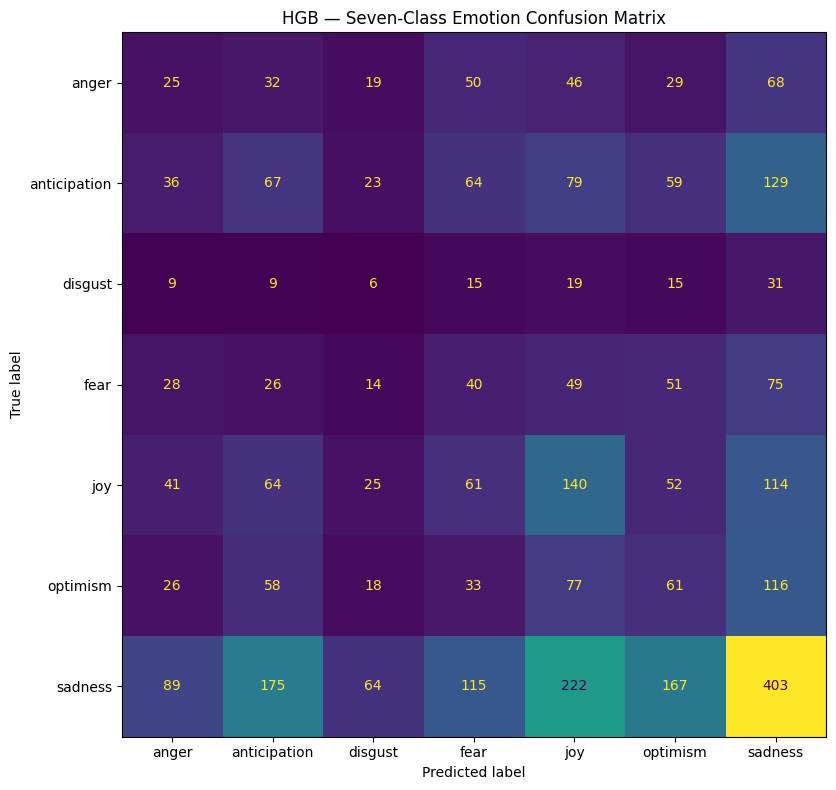

In [20]:
cm=confusion_matrix(y_test,y_pred,labels=EXPECTED_CLASSES)
fig,ax=plt.subplots(figsize=(10,8)); ConfusionMatrixDisplay(cm,display_labels=EXPECTED_CLASSES).plot(ax=ax,values_format="d",colorbar=False); ax.set_title("HGB — Seven-Class Emotion Confusion Matrix"); plt.tight_layout()
CONFUSION_PATH=RESULTS_DIR/"hist_gradient_boosting_confusion_matrix.png"; fig.savefig(CONFUSION_PATH,dpi=300,bbox_inches="tight"); plt.show(); plt.close(fig)

## 15. Model comparison plot

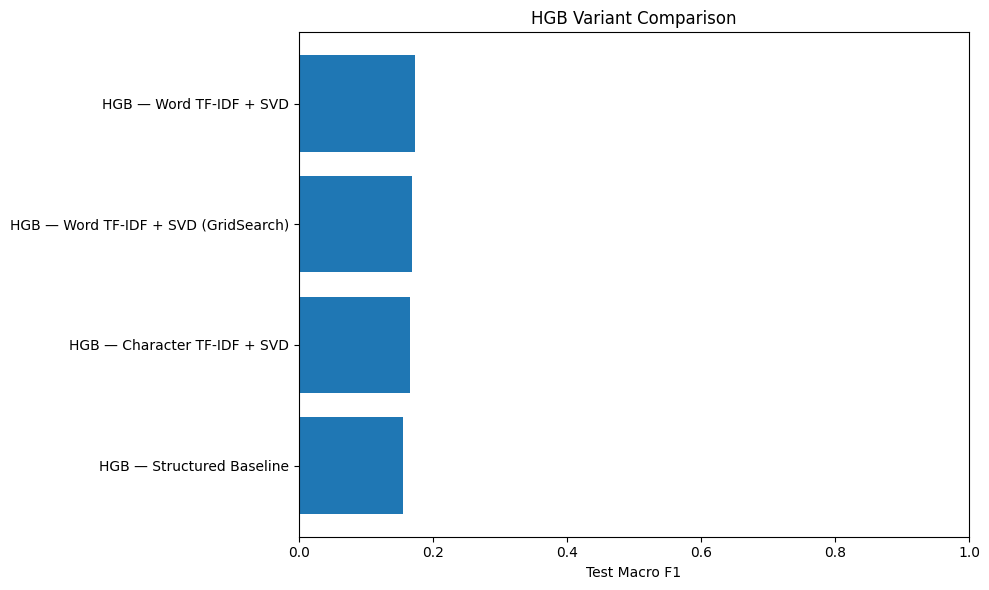

In [21]:
plot_df=comparison_df.sort_values("Test Macro F1")
fig,ax=plt.subplots(figsize=(10,6)); ax.barh(plot_df["Model"],plot_df["Test Macro F1"]); ax.set_xlabel("Test Macro F1"); ax.set_xlim(0,1); ax.set_title("HGB Variant Comparison"); plt.tight_layout()
COMPARISON_PLOT_PATH=RESULTS_DIR/"hist_gradient_boosting_model_comparison.png"; fig.savefig(COMPARISON_PLOT_PATH,dpi=300,bbox_inches="tight"); plt.show(); plt.close(fig)

## 16. Export standardized predictions CSV

In [22]:
proba=best_model.predict_proba(test_df["tokens_filtered"].fillna("").astype(str))
predictions=pd.DataFrame({"movie_name":test_df[GROUP_COL].astype(str).to_numpy(),"true_emotion":y_test.to_numpy(),"predicted_emotion":y_pred})
for i,cls in enumerate(best_model.classes_): predictions[f"prob_{cls}"]=proba[:,i]
PREDICTIONS_PATH=RESULTS_DIR/"hist_gradient_boosting_test_predictions.csv"
predictions.to_csv(PREDICTIONS_PATH,index=False)
print(PREDICTIONS_PATH, len(predictions))

/content/IT2011-AIML-Project/results/phase2/hist_gradient_boosting_test_predictions.csv 3234


## 17. Save final trained model

In [23]:
MODEL_PATH=RESULTS_DIR/"hist_gradient_boosting_model.joblib"
joblib.dump(best_model,MODEL_PATH)
print("Saved:",MODEL_PATH)

Saved: /content/IT2011-AIML-Project/results/phase2/hist_gradient_boosting_model.joblib


## 18. Export standardized results JSON

In [24]:
RESULTS_PATH=RESULTS_DIR/"hist_gradient_boosting_results.json"
payload={"model":"HistGradientBoostingClassifier","student_id":"IT25103066","task":"seven_class_emotion_classification","target_column":TARGET_COL,"group_column":GROUP_COL,"classes":EXPECTED_CLASSES,"random_state":RANDOM_STATE,"train_rows":int(len(train_df)),"test_rows":int(len(test_df)),"train_movies":int(len(train_movies)),"test_movies":int(len(test_movies)),"cv_protocol":"shared get_cv() grouped and stratified movie-level folds","cv_folds":int(len(cv_splits)),"scoring":"f1_macro","class_weights":{str(k):float(v) for k,v in class_weights.items()},"best_variant":"HGB — Word TF-IDF + SVD (GridSearch)","best_parameters":word_grid.best_params_,"metrics":metrics,"variant_comparison":comparison_df.to_dict(orient="records"),"artifacts":{"model":"results/phase2/hist_gradient_boosting_model.joblib","predictions":"results/phase2/hist_gradient_boosting_test_predictions.csv","confusion_matrix":"results/phase2/hist_gradient_boosting_confusion_matrix.png","comparison_plot":"results/phase2/hist_gradient_boosting_model_comparison.png"}}
with open(RESULTS_PATH,"w",encoding="utf-8") as f: json.dump(payload,f,indent=2)
print("Saved:",RESULTS_PATH)

Saved: /content/IT2011-AIML-Project/results/phase2/hist_gradient_boosting_results.json


## 19. Final integrity checks

In [25]:
assert TARGET_COL=="emotion" and len(EXPECTED_CLASSES)==7
assert TARGET_COL not in STRUCTURED_COLS and GROUP_COL not in STRUCTURED_COLS
assert train_movies.isdisjoint(test_movies)
assert len(cv_splits)==5
for tr,va in cv_splits: assert set(groups_train.iloc[tr]).isdisjoint(set(groups_train.iloc[va]))
assert RESULTS_PATH==REPO_ROOT/"results"/"phase2"/"hist_gradient_boosting_results.json" and RESULTS_PATH.exists()
assert PREDICTIONS_PATH==REPO_ROOT/"results"/"phase2"/"hist_gradient_boosting_test_predictions.csv" and PREDICTIONS_PATH.exists()
assert MODEL_PATH.exists() and len(predictions)==len(test_df)
assert {"movie_name","true_emotion","predicted_emotion"}.issubset(predictions.columns)
print("✓ Seven-class emotion target")
print("✓ No emotion target leakage")
print("✓ No Ratings target")
print("✓ make_split() and get_cv() protocol")
print("✓ Grouped 5-fold CV")
print("✓ Hyperparameter tuning + variant comparison")
print("✓ Required JSON + predictions CSV + model + plots exported")

✓ Seven-class emotion target
✓ No emotion target leakage
✓ No Ratings target
✓ make_split() and get_cv() protocol
✓ Grouped 5-fold CV
✓ Hyperparameter tuning + variant comparison
✓ Required JSON + predictions CSV + model + plots exported
